<a href="https://colab.research.google.com/github/Muhammad-Faiz-Firmansyah/2026_KECERDASAAN_BUATAN/blob/main/jobsheet7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Muhammad Faiz Firmansyah
- **NIM:** 4.33.25.0.16
- **Kelas:** TI-1A

## Menentukan Pertanyaan Bisnis

1. Bagaimana perubahan rata-rata PM2.5 setiap bulan?
2. Bagaimana hubungan antara temperatur dan konsentrasi PM2.5?

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Data Wrangling

### Gathering Data

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Air-quality-dataset.zip to Air-quality-dataset.zip


In [3]:
zip_name = next(iter(uploaded.keys()))

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall()

print("ZIP berhasil diekstrak.")

ZIP berhasil diekstrak.


In [4]:
csv_files = []
for root, dirs, files_in_dir in os.walk("."):
    for f in files_in_dir:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

csv_files

['./PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv',
 './PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv',
 './sample_data/california_housing_test.csv',
 './sample_data/mnist_train_small.csv',
 './sampl

### Assessing Data

In [5]:
csv_path = csv_files[0]
print("Menggunakan file:", csv_path)

df = pd.read_csv(csv_path)
df.head()

Menggunakan file: ./PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
CO,3197
NO2,1601
PM2.5,750
O3,664
SO2,663
PM10,553
wd,78
RAIN,20
DEWP,20
PRES,20


### Cleaning Data

In [8]:
df_clean = df.dropna().copy()

# Membuat kolom tanggal agar lebih mudah dianalisis.
df_clean["date"] = pd.to_datetime(df_clean[["year", "month", "day"]])

df_clean = df_clean.reset_index(drop=True)

df_clean.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01
2,6,2013,3,1,5,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi,2013-03-01
3,7,2013,3,1,6,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi,2013-03-01
4,8,2013,3,1,7,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi,2013-03-01


## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
df_clean.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date
count,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338.000000,30338
mean,18808.565759,2014.807832,6.530160,15.650109,11.500363,84.933156,110.991914,16.994466,53.717314,1316.524392,56.797482,13.623338,1012.879017,2.277794,0.061573,1.872510,2015-04-23 04:03:55.427516672
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000,2.000000,100.000000,1.000000,-16.800000,987.500000,-35.300000,0.000000,0.000000,2013-03-01 00:00:00
25%,11435.250000,2014.000000,4.000000,8.000000,5.000000,22.000000,38.000000,3.000000,27.000000,600.000000,11.673900,3.600000,1004.700000,-8.500000,0.000000,1.000000,2014-06-20 00:00:00
50%,19161.500000,2015.000000,7.000000,16.000000,11.000000,60.000000,87.000000,9.000000,47.000000,1000.000000,45.000000,14.600000,1012.400000,3.000000,0.000000,1.500000,2015-05-08 00:00:00
75%,26926.750000,2016.000000,10.000000,23.000000,18.000000,118.000000,152.000000,23.000000,73.000000,1600.000000,81.000000,23.000000,1020.900000,14.300000,0.000000,2.400000,2016-03-26 00:00:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,695.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,40.400000,1042.000000,28.800000,46.400000,10.500000,2017-02-28 00:00:00
std,9687.590750,1.124713,3.440944,8.800479,6.951066,85.283368,98.426262,20.555551,34.072328,1184.329763,57.850622,11.223178,10.004754,13.454891,0.791068,1.275355,NaN


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana rata-rata konsentrasi PM2.5 setiap bulan?

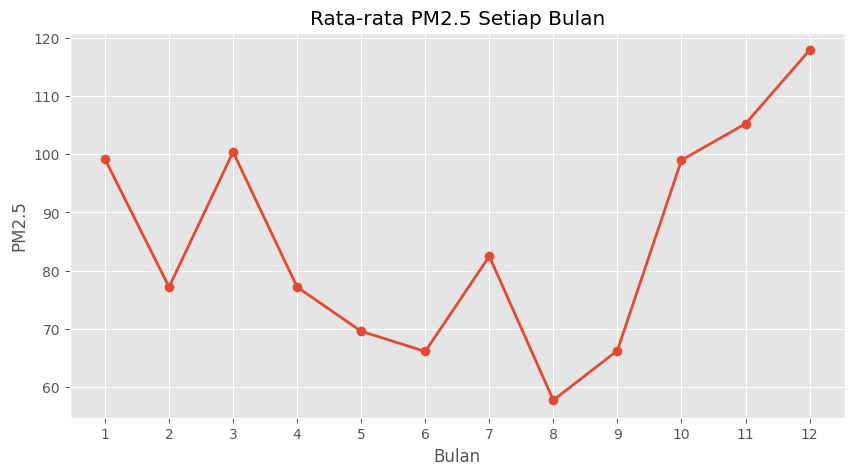

In [10]:
monthly_pm25 = df_clean.groupby("month")["PM2.5"].mean()

plt.figure(figsize=(10, 5))
monthly_pm25.plot(marker="o", linewidth=2)
plt.title("Rata-rata PM2.5 Setiap Bulan")
plt.xlabel("Bulan")
plt.ylabel("PM2.5")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

### Pertanyaan 2: Bagaimana hubungan antara temperatur dan konsentrasi PM2.5?

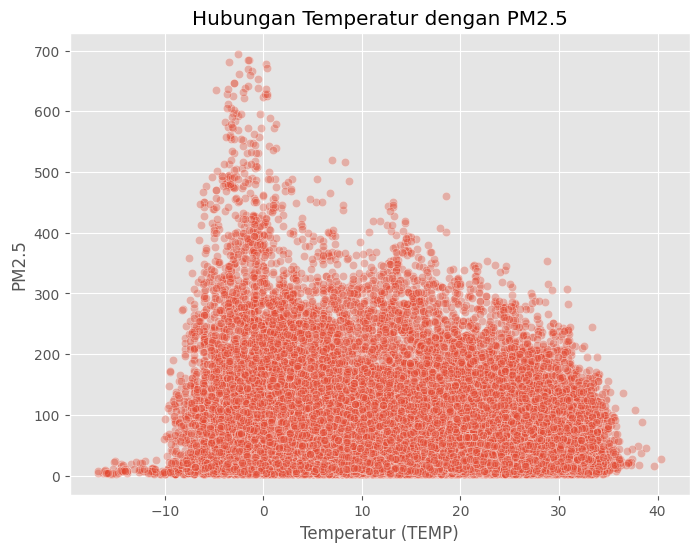

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x="TEMP", y="PM2.5", alpha=0.35)
plt.title("Hubungan Temperatur dengan PM2.5")
plt.xlabel("Temperatur (TEMP)")
plt.ylabel("PM2.5")
plt.show()

## Conclusion

1. Rata-rata konsentrasi PM2.5 berbeda pada setiap bulan, sehingga terdapat pola perubahan kualitas udara berdasarkan waktu.
2. Scatter plot menunjukkan adanya hubungan antara temperatur dan PM2.5, walaupun pola hubungannya tidak sepenuhnya linear.
3. Setelah data dibersihkan, dataset lebih siap digunakan untuk eksplorasi dan analisis lanjutan.